/tmp/ipykernel_14049/2205349676.py:38: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig(f"{path}/pie_{col}.png")
/tmp/ipykernel_14049/2205349676.py:58: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig(f"{path}/line_{col}-{cat}.png")


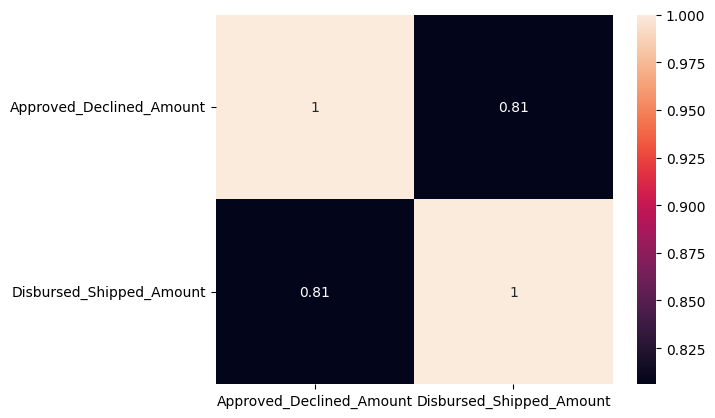

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate

path = "img/Semana 6"

def print_tabulate(df:pd.DataFrame)-> pd.DataFrame:
    print(tabulate(df, headers= df.columns, tablefmt='orgtbl'))

df = pd.read_csv("csv/aprovCreditos.csv", index_col=False,
    dtype={
        "Primary Export Product NAICS/SIC code": int
    }
)
os.makedirs(path, exist_ok=True)

colNumericas = [ "Approved_Declined_Amount", "Disbursed_Shipped_Amount"]

colCategoricas = ["Program", "Country", "Term", "Primary_Applicant"]


for col in colNumericas:
    df[col].hist(figsize=(10, 6))
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.savefig(f"{path}/histograma_{col}.png")
    plt.close()


for col in colCategoricas:
    counts = df[col].value_counts()
    counts.plot(kind="pie", figsize=(10, 10), autopct="%1.1f%%")
    plt.title(f"Pie chart of {col}")
    plt.savefig(f"{path}/pie_{col}.png")
    plt.close()

for i in range(len(colNumericas)):
    for j in range(i + 1, len(colNumericas)):
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(df[colNumericas[i]], df[colNumericas[j]])
        ax.set_xlabel(colNumericas[i])
        ax.set_ylabel(colNumericas[j])
        plt.title(f"Scatter {colNumericas[i]} vs {colNumericas[j]}")
        plt.savefig(f"{path}/scatter_{colNumericas[i]}_vs_{colNumericas[j]}.png")
        plt.close()
        
for cat in colCategoricas:
    for col in colNumericas:
        df_grouped = df.groupby(cat)[col].mean().reset_index()
        fig, ax = plt.subplots(figsize=(18, 10))
        ax.plot(df_grouped[cat], df_grouped[col])
        plt.xticks(rotation=90)
        plt.title(f"Mean {col} by {cat}")
        plt.savefig(f"{path}/line_{col}-{cat}.png")
        plt.close()

hmap = sns.heatmap(df[colNumericas].corr(), annot=True)